  CNN jako alternatywne podejscie do wykrywania spoofingo gps bezpośrenio z danych binarnych bez wydowbywania parametrów
 Celem tego eksperymentu jest sprawdzenie jak prosta sieć konwolucyjna  1D  potrafi odróżnić probki sygnalu gps-a z i bez spoofingu




W tej wersji:

- `C7` **nie jest używany** 
- Zamiast udawać dwa różne clean scenariusze, używamy jednego clean recordingu `C5` i dzielimy go czasowo:
  - `C5`, `0–90 s` → train clean,
  - `C5`, `90–105 s` → gap, pominięte,
  - `C5`, `105–150 s` → val clean.
- `SS33` pozostaje held-out testem z etykietami czasowymi z README:
  - spoofing startuje około `70 s`,
  - trwa około `80 s`,
  - kończy się około `150 s`.
- Threshold klasyfikacji jest dobierany na walidacji (`C5_val_segment + SS29`), a potem używany bez zmian na `SS33`.

To jest nadal walidacja prototypowa, bo clean train i clean val pochodzą z tego samego nagrania `C5`, ale jest to uczciwsze niż traktowanie identycznego `C7` jako osobnego scenariusza.


In [2]:
# Dane wejsciowe zapisaine śą jakow raw I/O zapisanymi w formacie int8
# w naszym podejjściu każde okno sygnałów przekształcane zostaje do tenosra o wymiarze[2,N]

#Gdzie kanał zero to skłądowa I sygnalu a kanał pierwszy to skladowa Q

# Model CNN uczy sie wzorców w sygnale zamiast korzystać z cieżkgo licznia cech 

In [35]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd

PROJECT_DIR = Path("/workspace/gps-spoofing")
MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"

MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

In [36]:
import gc
import torch

for name in [
    "model", "optimizer",
    "train_ds", "val_ds",
    "train_loader", "val_loader",
    "sampler",
    "history", "history_df",
]:
    if name in globals():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()

print("Reset done")

Reset done


In [37]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path("/workspace/gps-spoofing")
RAW_DIR = PROJECT_DIR / "raw"

raw_files = sorted(RAW_DIR.glob("*.bin"))
completed_files = [p for p in raw_files if not Path(str(p) + ".aria2").exists()]

def label_from_name(name: str) -> int:
    lower = name.lower()
    if "clean" in lower or lower.startswith("c5") or lower.startswith("c7"):
        return 0
    return 1

pd.DataFrame([
    {
        "file": p.name,
        "size_GB": p.stat().st_size / 1024**3,
        "label": label_from_name(p.name),
        "class": "clean" if label_from_name(p.name) == 0 else "spoofing",
    }
    for p in completed_files
])

,file,size_GB,label,class
0,C5_clean_no_multipath__Clear-Sky_Signal_C-5.bin,27.939521,0,clean
1,C7_clean_multipath__Clearsky_signal_C-7.bin,27.939521,0,clean
2,SS17_no_multipath_1_spoofer__SS-17_GPS_Static_...,27.939521,1,spoofing
3,SS18_no_multipath_2_spoofers__SS-18_GPS_Static...,27.939521,1,spoofing
4,SS20_no_multipath_4_spoofers__SS-20_GPS_Static...,27.939521,1,spoofing
5,SS27_multipath_1_spoofer__SS-27_GPS_Static_Mul...,27.939521,1,spoofing
6,SS28_multipath_2_spoofers__SS-28_GPS_Static_Mu...,27.939521,1,spoofing
7,SS29_multipath_4_spoofers__SS-29_GPS_Static_Mu...,27.939521,1,spoofing
8,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,37.252821,1,spoofing


In [6]:
from pathlib import Path
import random
import math
import os
import copy

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm.auto import tqdm

from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_DIR = Path("/workspace/gps-spoofing")
RAW_DIR = PROJECT_DIR / "raw"
MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"

MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

print("Project:", PROJECT_DIR)
print("Raw dir:", RAW_DIR)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", torch.cuda.get_device_properties(0).total_memory / 1024**3)

Project: /workspace/gps-spoofing
Raw dir: /workspace/gps-spoofing/raw
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM GB: 94.97076416015625


In [7]:
from pathlib import Path
import pandas as pd

RAW_DIR = PROJECT_DIR / "raw"

def label_from_name(name: str) -> int:
    lower = name.lower()
    if "clean" in lower or lower.startswith("c5") or lower.startswith("c7"):
        return 0
    return 1

raw_files = sorted(RAW_DIR.glob("*.bin"))
completed_files = [p for p in raw_files if not Path(str(p) + ".aria2").exists()]

rows = []
for p in completed_files:
    label = label_from_name(p.name)
    rows.append({
        "file": p.name,
        "size_GB": p.stat().st_size / 1024**3,
        "label": label,
        "class": "clean" if label == 0 else "spoofing",
    })

files_df = pd.DataFrame(rows)
files_df

,file,size_GB,label,class
0,C5_clean_no_multipath__Clear-Sky_Signal_C-5.bin,27.939521,0,clean
1,C7_clean_multipath__Clearsky_signal_C-7.bin,27.939521,0,clean
2,SS17_no_multipath_1_spoofer__SS-17_GPS_Static_...,27.939521,1,spoofing
3,SS18_no_multipath_2_spoofers__SS-18_GPS_Static...,27.939521,1,spoofing
4,SS20_no_multipath_4_spoofers__SS-20_GPS_Static...,27.939521,1,spoofing
5,SS27_multipath_1_spoofer__SS-27_GPS_Static_Mul...,27.939521,1,spoofing
6,SS28_multipath_2_spoofers__SS-28_GPS_Static_Mu...,27.939521,1,spoofing
7,SS29_multipath_4_spoofers__SS-29_GPS_Static_Mu...,27.939521,1,spoofing
8,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,37.252821,1,spoofing


In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
from collections import Counter

PROJECT_DIR = Path("/workspace/gps-spoofing")
RAW_DIR = PROJECT_DIR / "raw"

# Częstotliwość próbkowania z README/descriptoru.
SAMPLE_RATE_HZ = 50_000_000
RAW_DTYPE = np.dtype("<i2")  # int16 little-endian: I=int16, Q=int16


def scenario_key(name: str) -> str:
    """Zwraca uproszczony identyfikator scenariusza, np. C5, C7, SS33."""
    upper = name.upper()
    m = re.search(r"(SS|C)[-_ ]?(\d+)", upper)
    if m:
        return f"{m.group(1)}{int(m.group(2))}"
    return upper


def label_from_name(name: str) -> int:
    """
    Etykieta plikowa, używana tylko jako fallback.
    0 = clean
    1 = scenariusz zawierający spoofing
    """
    key = scenario_key(name)
    lower = name.lower()
    if key.startswith("C") or "clean" in lower:
        return 0
    return 1


# ----------------------------
# Ground truth czasowy
# ----------------------------

# SS33 z README:
# - spoofing injection po około 70 s,
# - spoofing duration około 80 s,
# - usunięcie około 150 s.
ATTACK_INTERVALS_S = {
    "SS33": [(70.0, 150.0)],
}

# Pomijamy niepewne okolice przejść, bo README podaje wartości przybliżone.
IGNORE_INTERVALS_S = {
    "SS33": [(65.0, 70.0), (150.0, 152.0)],
}

# Dla SS17/18/20/27/28/29 nie mamy opóźnionego spoofingu z README,
# więc traktujemy je jako static spoofing przez cały plik.
UNKNOWN_SPOOF_POLICY = "file_level"

# ----------------------------
# Clean split czasowy
# ----------------------------

# C5 i C7 są bajtowo identyczne, więc C7 NIE jest niezależnym clean.
# Używamy tylko C5 i dzielimy go czasowo na clean train/val.
# Gap 90–105 s ogranicza leakage przez sąsiednie, bardzo podobne okna.
CLEAN_TIME_SPLITS_S = {
    "C5": {
        "train": [(0.0, 90.0)],
        "val": [(105.0, 150.0)],
    }
}

EXCLUDED_SCENARIOS = {
    "C7": "C7 appears byte-identical to C5; excluded to avoid clean leakage",
}


def overlaps(a_start: float, a_end: float, b_start: float, b_end: float) -> bool:
    return (a_end > b_start) and (a_start < b_end)


def window_overlaps_any_interval(window_start_s: float, window_end_s: float, intervals) -> bool:
    return any(overlaps(window_start_s, window_end_s, s, e) for s, e in intervals)


def label_window_from_time(file_name: str, window_start_s: float, window_end_s: float):
    """
    Zwraca label konkretnego okna:
    0    = clean
    1    = aktywny spoofing
    None = okno pomijane, np. transition albo brak etykiety przy UNKNOWN_SPOOF_POLICY='skip'
    """
    key = scenario_key(file_name)
    file_label = label_from_name(file_name)

    # Pliki clean są clean w całości, ewentualne ograniczenie czasowe robi dataset przez CLEAN_TIME_SPLITS_S.
    if file_label == 0:
        return 0

    # Pomiń niepewne przejścia, jeśli zdefiniowano.
    for ignore_start_s, ignore_end_s in IGNORE_INTERVALS_S.get(key, []):
        if overlaps(window_start_s, window_end_s, ignore_start_s, ignore_end_s):
            return None

    # Jeżeli mamy jawny przedział aktywnego ataku, tylko jego część dostaje label=1.
    if key in ATTACK_INTERVALS_S:
        for attack_start_s, attack_end_s in ATTACK_INTERVALS_S[key]:
            if overlaps(window_start_s, window_end_s, attack_start_s, attack_end_s):
                return 1
        return 0

    # Fallback dla SSxx bez temporal labels.
    if UNKNOWN_SPOOF_POLICY == "file_level":
        return 1
    if UNKNOWN_SPOOF_POLICY == "skip":
        return None

    raise ValueError(f"Nieznany UNKNOWN_SPOOF_POLICY: {UNKNOWN_SPOOF_POLICY}")


raw_files = sorted(RAW_DIR.glob("*.bin"))
completed_files = [p for p in raw_files if not Path(str(p) + ".aria2").exists()]

files_df = pd.DataFrame([
    {
        "file": p.name,
        "scenario": scenario_key(p.name),
        "size_GB": p.stat().st_size / 1024**3,
        "file_level_label": label_from_name(p.name),
        "file_level_class": "clean" if label_from_name(p.name) == 0 else "spoofing_scenario",
        "has_temporal_attack_intervals": scenario_key(p.name) in ATTACK_INTERVALS_S,
        "excluded_from_experiment": scenario_key(p.name) in EXCLUDED_SCENARIOS,
        "excluded_reason": EXCLUDED_SCENARIOS.get(scenario_key(p.name), ""),
    }
    for p in completed_files
])

print("Completed files:", len(completed_files))
display(files_df.sort_values(["excluded_from_experiment", "file_level_label", "scenario", "file"]))

# Opcjonalna kontrola duplikatu C5/C7 — szybki sampled hash.
# Jeżeli C7 jest identyczny z C5, nie jest używany dalej.
import hashlib

def sampled_file_hash(path, n_chunks=32, chunk_size=1024 * 1024):
    size = path.stat().st_size
    if size < chunk_size:
        offsets = [0]
    else:
        offsets = np.linspace(0, max(0, size - chunk_size), n_chunks, dtype=np.int64)
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for off in offsets:
            f.seek(int(off))
            h.update(f.read(chunk_size))
    return h.hexdigest()

c5_candidates = [p for p in completed_files if scenario_key(p.name) == "C5"]
c7_candidates = [p for p in completed_files if scenario_key(p.name) == "C7"]

if c5_candidates and c7_candidates:
    c5_hash = sampled_file_hash(c5_candidates[0])
    c7_hash = sampled_file_hash(c7_candidates[0])
    print("C5 sampled hash:", c5_hash)
    print("C7 sampled hash:", c7_hash)
    print("C5/C7 sampled hashes equal:", c5_hash == c7_hash)
    if c5_hash == c7_hash:
        print("UWAGA: C7 pomijamy, bo wygląda jak kopia C5.")

usable_files = [p for p in completed_files if scenario_key(p.name) not in EXCLUDED_SCENARIOS]

# Split scenariuszowy.
# C5 występuje w train i val, ale różne fragmenty czasu są wybierane przez time_split_name w RawIQDatasetInt16.
train_scenarios = ["C5", "SS17", "SS18", "SS20", "SS27", "SS28"]
val_scenarios = ["C5", "SS29"]
test_scenarios = ["SS33"]


def files_for_scenarios(files, scenarios):
    scenarios = set(scenarios)
    return [p for p in files if scenario_key(p.name) in scenarios]

train_files = files_for_scenarios(usable_files, train_scenarios)
val_files = files_for_scenarios(usable_files, val_scenarios)
test_files = files_for_scenarios(usable_files, test_scenarios)

train_names = {p.name for p in train_files}
val_names = {p.name for p in val_files}
test_names = {p.name for p in test_files}

assert len(train_files) > 0, "Brak plików train_files — sprawdź train_scenarios."
assert len(val_files) > 0, "Brak plików val_files — sprawdź val_scenarios."

# C5 może być wspólny między train/val, ale tylko dlatego, że używamy rozłącznych segmentów czasowych.
train_val_overlap = train_names & val_names
allowed_train_val_overlap = {
    p.name for p in completed_files
    if scenario_key(p.name) in CLEAN_TIME_SPLITS_S
}
unexpected_train_val_overlap = train_val_overlap - allowed_train_val_overlap

assert len(unexpected_train_val_overlap) == 0, f"Leakage: nieoczekiwane te same pliki w train i val: {unexpected_train_val_overlap}"
assert len(train_names & test_names) == 0, f"Leakage: te same pliki w train i test: {train_names & test_names}"
assert len(val_names & test_names) == 0, f"Leakage: te same pliki w val i test: {val_names & test_names}"

if train_val_overlap:
    print("Kontrolowany overlap train/val:", train_val_overlap)
    print("Te pliki są dzielone czasowo przez CLEAN_TIME_SPLITS_S:", CLEAN_TIME_SPLITS_S)

split_rows = []
for split_name, split_files in [("train", train_files), ("val", val_files), ("test", test_files)]:
    for p in split_files:
        key = scenario_key(p.name)
        split_rows.append({
            "split": split_name,
            "file": p.name,
            "scenario": key,
            "time_split_used": split_name if key in CLEAN_TIME_SPLITS_S and split_name in CLEAN_TIME_SPLITS_S[key] else "full_file",
            "time_intervals_s": CLEAN_TIME_SPLITS_S.get(key, {}).get(split_name, "full_file"),
            "file_level_label": label_from_name(p.name),
            "file_level_class": "clean" if label_from_name(p.name) == 0 else "spoofing_scenario",
            "has_temporal_attack_intervals": key in ATTACK_INTERVALS_S,
            "size_GB": p.stat().st_size / 1024**3,
        })

split_df = pd.DataFrame(split_rows)
display(split_df.sort_values(["split", "file_level_label", "scenario", "file"]))

print("Train file-level counts:", Counter(label_from_name(p.name) for p in train_files))
print("Val file-level counts:", Counter(label_from_name(p.name) for p in val_files))
print("Test file-level counts:", Counter(label_from_name(p.name) for p in test_files))
print("Clean time splits:", CLEAN_TIME_SPLITS_S)
print("Temporal attack intervals:", ATTACK_INTERVALS_S)
print("Ignore intervals:", IGNORE_INTERVALS_S)
print("Unknown spoof policy:", UNKNOWN_SPOOF_POLICY)


Completed files: 9


,file,scenario,size_GB,file_level_label,file_level_class,has_temporal_attack_intervals,excluded_from_experiment,excluded_reason
0,C5_clean_no_multipath__Clear-Sky_Signal_C-5.bin,C5,27.939521,0,clean,False,False,
2,SS17_no_multipath_1_spoofer__SS-17_GPS_Static_...,SS17,27.939521,1,spoofing_scenario,False,False,
3,SS18_no_multipath_2_spoofers__SS-18_GPS_Static...,SS18,27.939521,1,spoofing_scenario,False,False,
4,SS20_no_multipath_4_spoofers__SS-20_GPS_Static...,SS20,27.939521,1,spoofing_scenario,False,False,
5,SS27_multipath_1_spoofer__SS-27_GPS_Static_Mul...,SS27,27.939521,1,spoofing_scenario,False,False,
6,SS28_multipath_2_spoofers__SS-28_GPS_Static_Mu...,SS28,27.939521,1,spoofing_scenario,False,False,
7,SS29_multipath_4_spoofers__SS-29_GPS_Static_Mu...,SS29,27.939521,1,spoofing_scenario,False,False,
8,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,SS33,37.252821,1,spoofing_scenario,True,False,
1,C7_clean_multipath__Clearsky_signal_C-7.bin,C7,27.939521,0,clean,False,True,C7 appears byte-identical to C5; excluded to a...


C5 sampled hash: 68b1424bcdd4f5320cc2a07ece1fa01a6af073e85e0057968de5e0bfb030b31b
C7 sampled hash: 68b1424bcdd4f5320cc2a07ece1fa01a6af073e85e0057968de5e0bfb030b31b
C5/C7 sampled hashes equal: True
UWAGA: C7 pomijamy, bo wygląda jak kopia C5.
Kontrolowany overlap train/val: {'C5_clean_no_multipath__Clear-Sky_Signal_C-5.bin'}
Te pliki są dzielone czasowo przez CLEAN_TIME_SPLITS_S: {'C5': {'train': [(0.0, 90.0)], 'val': [(105.0, 150.0)]}}


,split,file,scenario,time_split_used,time_intervals_s,file_level_label,file_level_class,has_temporal_attack_intervals,size_GB
8,test,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,SS33,full_file,full_file,1,spoofing_scenario,True,37.252821
0,train,C5_clean_no_multipath__Clear-Sky_Signal_C-5.bin,C5,train,"[(0.0, 90.0)]",0,clean,False,27.939521
1,train,SS17_no_multipath_1_spoofer__SS-17_GPS_Static_...,SS17,full_file,full_file,1,spoofing_scenario,False,27.939521
2,train,SS18_no_multipath_2_spoofers__SS-18_GPS_Static...,SS18,full_file,full_file,1,spoofing_scenario,False,27.939521
3,train,SS20_no_multipath_4_spoofers__SS-20_GPS_Static...,SS20,full_file,full_file,1,spoofing_scenario,False,27.939521
4,train,SS27_multipath_1_spoofer__SS-27_GPS_Static_Mul...,SS27,full_file,full_file,1,spoofing_scenario,False,27.939521
5,train,SS28_multipath_2_spoofers__SS-28_GPS_Static_Mu...,SS28,full_file,full_file,1,spoofing_scenario,False,27.939521
6,val,C5_clean_no_multipath__Clear-Sky_Signal_C-5.bin,C5,val,"[(105.0, 150.0)]",0,clean,False,27.939521
7,val,SS29_multipath_4_spoofers__SS-29_GPS_Static_Mu...,SS29,full_file,full_file,1,spoofing_scenario,False,27.939521


Train file-level counts: Counter({1: 5, 0: 1})
Val file-level counts: Counter({0: 1, 1: 1})
Test file-level counts: Counter({1: 1})
Clean time splits: {'C5': {'train': [(0.0, 90.0)], 'val': [(105.0, 150.0)]}}
Temporal attack intervals: {'SS33': [(70.0, 150.0)]}
Ignore intervals: {'SS33': [(65.0, 70.0), (150.0, 152.0)]}
Unknown spoof policy: file_level


In [9]:
import random
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import Dataset

class RawIQDatasetInt16(Dataset):
    def __init__(
        self,
        raw_files,
        window_samples=16_384,
        max_windows_per_file=1_000,
        normalize=True,
        per_window_standardize=True,
        sample_rate_hz=50_000_000,
        use_temporal_labels=True,
        time_split_name=None,
        shuffle_index=True,
    ):
        self.raw_files = list(raw_files)
        self.window_samples = int(window_samples)
        self.max_windows_per_file = int(max_windows_per_file)
        self.normalize = bool(normalize)
        self.per_window_standardize = bool(per_window_standardize)
        self.sample_rate_hz = float(sample_rate_hz)
        self.use_temporal_labels = bool(use_temporal_labels)
        self.time_split_name = time_split_name

        self.index = []
        self.skipped_windows = []
        self._memmaps = {}

        bytes_per_value = np.dtype(np.int16).itemsize

        for file_idx, p in enumerate(self.raw_files):
            if str(p).endswith(".aria2"):
                continue
            if Path(str(p) + ".aria2").exists():
                continue

            file_size = p.stat().st_size
            value_count = file_size // bytes_per_value
            complex_count = value_count // 2
            total_windows = complex_count // self.window_samples

            if total_windows <= 0:
                continue

            key = scenario_key(p.name)

            # Jeżeli to plik z rozłącznym clean split, próbkujemy tylko z dozwolonego przedziału czasu.
            split_cfg = CLEAN_TIME_SPLITS_S.get(key)
            if self.time_split_name is not None and split_cfg is not None:
                allowed_intervals = split_cfg.get(self.time_split_name, [])
                candidate_windows = []

                for start_s, end_s in allowed_intervals:
                    start_w = max(0, int(np.floor(start_s * self.sample_rate_hz / self.window_samples)))
                    end_w = min(total_windows - 1, int(np.ceil(end_s * self.sample_rate_hz / self.window_samples)) - 1)

                    if end_w >= start_w:
                        candidate_windows.append(np.arange(start_w, end_w + 1, dtype=np.int64))

                if len(candidate_windows) == 0:
                    continue

                candidate_windows = np.unique(np.concatenate(candidate_windows))
                used_windows = min(len(candidate_windows), self.max_windows_per_file)
                selected_positions = np.linspace(0, len(candidate_windows) - 1, used_windows, dtype=np.int64)
                window_ids = candidate_windows[selected_positions]
            else:
                # Dla zwykłych plików bierzemy okna równomiernie z całego pliku.
                used_windows = min(total_windows, self.max_windows_per_file)
                window_ids = np.linspace(0, total_windows - 1, used_windows, dtype=np.int64)

            for w in window_ids:
                w = int(w)
                window_start_s = (w * self.window_samples) / self.sample_rate_hz
                window_end_s = ((w + 1) * self.window_samples) / self.sample_rate_hz

                # Dodatkowe zabezpieczenie: gdy split czasowy istnieje, ale okno nachodzi poza dozwolone przedziały.
                if self.time_split_name is not None and split_cfg is not None:
                    allowed_intervals = split_cfg.get(self.time_split_name, [])
                    if not window_overlaps_any_interval(window_start_s, window_end_s, allowed_intervals):
                        self.skipped_windows.append({
                            "file": p.name,
                            "scenario": key,
                            "window_idx": w,
                            "window_start_s": window_start_s,
                            "window_end_s": window_end_s,
                            "reason": f"outside_{self.time_split_name}_time_split",
                        })
                        continue

                if self.use_temporal_labels:
                    label = label_window_from_time(p.name, window_start_s, window_end_s)
                else:
                    label = label_from_name(p.name)

                if label is None:
                    self.skipped_windows.append({
                        "file": p.name,
                        "scenario": key,
                        "window_idx": w,
                        "window_start_s": window_start_s,
                        "window_end_s": window_end_s,
                        "reason": "temporal_label_none_or_ignore_interval",
                    })
                    continue

                self.index.append((file_idx, w, int(label), window_start_s, window_end_s, key))

        if shuffle_index:
            random.shuffle(self.index)

    def __len__(self):
        return len(self.index)

    def _get_memmap(self, file_idx):
        if file_idx not in self._memmaps:
            self._memmaps[file_idx] = np.memmap(
                self.raw_files[file_idx],
                dtype=np.int16,
                mode="r",
            )
        return self._memmaps[file_idx]

    def get_metadata(self, idx):
        file_idx, window_idx, label, window_start_s, window_end_s, scen = self.index[idx]
        return {
            "file": self.raw_files[file_idx].name,
            "file_idx": file_idx,
            "scenario": scen,
            "window_idx": window_idx,
            "window_start_s": window_start_s,
            "window_end_s": window_end_s,
            "label": label,
        }

    def __getitem__(self, idx):
        file_idx, window_idx, label, window_start_s, window_end_s, scen = self.index[idx]
        mm = self._get_memmap(file_idx)

        start = window_idx * self.window_samples * 2
        end = start + self.window_samples * 2

        raw = mm[start:end]
        iq = raw.reshape(-1, 2).astype(np.float32)

        if self.normalize:
            # Skala int16 -> około [-1, 1].
            iq = iq / 32768.0

        if self.per_window_standardize:
            # Usuwa łatwy artefakt typu: jedna klasa ma po prostu większy gain/RMS.
            iq = iq - iq.mean(axis=0, keepdims=True)
            iq = iq / (iq.std(axis=0, keepdims=True) + 1e-6)

        # Conv1d oczekuje [channels, length], czyli [2, N].
        x = torch.from_numpy(iq.T.copy())
        y = torch.tensor(label, dtype=torch.float32)

        return x, y


def dataset_index_df(ds: RawIQDatasetInt16) -> pd.DataFrame:
    rows = []
    for file_idx, window_idx, label, window_start_s, window_end_s, scen in ds.index:
        rows.append({
            "file": ds.raw_files[file_idx].name,
            "scenario": scen,
            "time_split_name": ds.time_split_name,
            "window_idx": window_idx,
            "window_start_s": window_start_s,
            "window_end_s": window_end_s,
            "label": int(label),
        })
    return pd.DataFrame(rows)


In [10]:
WINDOW_SAMPLES = 131072
MAX_WINDOWS_PER_FILE = 2_000

train_ds = RawIQDatasetInt16(
    train_files,
    window_samples=WINDOW_SAMPLES,
    max_windows_per_file=MAX_WINDOWS_PER_FILE,
    normalize=True,
    per_window_standardize=True,
    sample_rate_hz=SAMPLE_RATE_HZ,
    use_temporal_labels=True,
    time_split_name="train",
)

val_ds = RawIQDatasetInt16(
    val_files,
    window_samples=WINDOW_SAMPLES,
    max_windows_per_file=MAX_WINDOWS_PER_FILE,
    normalize=True,
    per_window_standardize=True,
    sample_rate_hz=SAMPLE_RATE_HZ,
    use_temporal_labels=True,
    time_split_name="val",
)

# SS33 jako osobny held-out test. Bez time_split_name, bo labelowanie robi ATTACK_INTERVALS_S/IGNORE_INTERVALS_S.
test_ds = RawIQDatasetInt16(
    test_files,
    window_samples=WINDOW_SAMPLES,
    max_windows_per_file=MAX_WINDOWS_PER_FILE,
    normalize=True,
    per_window_standardize=True,
    sample_rate_hz=SAMPLE_RATE_HZ,
    use_temporal_labels=True,
    time_split_name=None,
) if len(test_files) > 0 else None

print("Train windows:", len(train_ds), "skipped:", len(train_ds.skipped_windows))
print("Val windows:", len(val_ds), "skipped:", len(val_ds.skipped_windows))
print("Test windows:", len(test_ds) if test_ds is not None else 0, "skipped:", len(test_ds.skipped_windows) if test_ds is not None else 0)

assert len(train_ds) > 0, "train_ds jest pusty."
assert len(val_ds) > 0, "val_ds jest pusty."

train_index_df = dataset_index_df(train_ds)
val_index_df = dataset_index_df(val_ds)
test_index_df = dataset_index_df(test_ds) if test_ds is not None else pd.DataFrame()

print("\nTrain label counts:")
print(train_index_df["label"].value_counts().sort_index())
print("\nVal label counts:")
print(val_index_df["label"].value_counts().sort_index())
if test_ds is not None:
    print("\nTest label counts:")
    print(test_index_df["label"].value_counts().sort_index())

print("\nTrain labels by scenario:")
display(train_index_df.groupby(["scenario", "label"]).size().unstack(fill_value=0))
print("\nVal labels by scenario:")
display(val_index_df.groupby(["scenario", "label"]).size().unstack(fill_value=0))
if test_ds is not None:
    print("\nTest labels by scenario:")
    display(test_index_df.groupby(["scenario", "label"]).size().unstack(fill_value=0))

print("\nC5 train time range:")
display(train_index_df[train_index_df["scenario"] == "C5"][["window_start_s", "window_end_s"]].agg(["min", "max"]))
print("\nC5 val time range:")
display(val_index_df[val_index_df["scenario"] == "C5"][["window_start_s", "window_end_s"]].agg(["min", "max"]))

# Zabezpieczenie przed bezsensowną walidacją jedną klasą.
assert train_index_df["label"].nunique() == 2, "Train ma tylko jedną klasę po etykietach czasowych."
assert val_index_df["label"].nunique() == 2, "Val ma tylko jedną klasę po etykietach czasowych."
if test_ds is not None:
    assert test_index_df["label"].nunique() == 2, "Test ma tylko jedną klasę — dla SS33 powinny być clean i spoof po etykietach czasowych."

# Kontrola: C7 nie powinien się pojawić w żadnym zbiorze.
for split_name, idx_df in [("train", train_index_df), ("val", val_index_df), ("test", test_index_df)]:
    if len(idx_df) > 0:
        assert "C7" not in set(idx_df["scenario"]), f"C7 pojawił się w {split_name}, a powinien być wykluczony."

x0, y0 = train_ds[0]
print("\nx shape:", x0.shape)
print("y:", y0)
print("x min:", x0.min().item())
print("x max:", x0.max().item())
print("x mean:", x0.mean().item())
print("x std:", x0.std().item())
print("channel mean I/Q:", x0[0].mean().item(), x0[1].mean().item())
print("channel std I/Q:", x0[0].std().item(), x0[1].std().item())


Train windows: 12000 skipped: 0
Val windows: 4000 skipped: 0
Test windows: 1930 skipped: 70

Train label counts:
label
0     2000
1    10000
Name: count, dtype: int64

Val label counts:
label
0    2000
1    2000
Name: count, dtype: int64

Test label counts:
label
0    1130
1     800
Name: count, dtype: int64

Train labels by scenario:


label,0,1
scenario,,
C5,2000,0
SS17,0,2000
SS18,0,2000
SS20,0,2000
SS27,0,2000
SS28,0,2000



Val labels by scenario:


label,0,1
scenario,,
C5,2000,0
SS29,0,2000



Test labels by scenario:


...


C5 train time range:


,window_start_s,window_end_s
min,0.000000,0.002621
max,89.999278,90.001900



C5 val time range:


,window_start_s,window_end_s
min,104.999158,105.001779
max,149.996175,149.998797



x shape: torch.Size([2, 131072])
y: tensor(1.)
x min: -4.134782791137695
x max: 4.203527450561523
x mean: -3.7192367017269135e-06
x std: 1.000020980834961
channel mean I/Q: 5.238689482212067e-09 -7.443130016326904e-06
channel std I/Q: 1.0000255107879639 1.0000202655792236


In [11]:
# Kontrola możliwych artefaktów: RMS/std/mean dla faktycznie użytych okien.
# W przeciwieństwie do starszej wersji, statystyki liczymy z ds.index, czyli respektujemy C5 train/val split czasowy.

import numpy as np
import pandas as pd

RAW_DTYPE = np.dtype("<i2")

def quick_dataset_stats(ds, split_name, n_windows=300):
    if ds is None or len(ds) == 0:
        return pd.DataFrame()

    sample_ids = np.linspace(0, len(ds.index) - 1, min(n_windows, len(ds.index)), dtype=np.int64)
    rows = []

    for idx in sample_ids:
        file_idx, window_idx, label, window_start_s, window_end_s, scen = ds.index[int(idx)]
        p = ds.raw_files[file_idx]
        mm = ds._get_memmap(file_idx)

        start = window_idx * ds.window_samples * 2
        end = start + ds.window_samples * 2

        raw = mm[start:end]
        iq = raw.reshape(-1, 2).astype(np.float32) / 32768.0

        rows.append({
            "split": split_name,
            "file": p.name,
            "scenario": scen,
            "time_split_name": ds.time_split_name,
            "label": int(label),
            "class": "clean" if int(label) == 0 else "spoofing",
            "window_start_s": window_start_s,
            "window_end_s": window_end_s,
            "mean": float(iq.mean()),
            "std": float(iq.std()),
            "rms": float(np.sqrt(np.mean(iq ** 2))),
            "max_abs": float(np.max(np.abs(iq))),
        })

    return pd.DataFrame(rows)

stats_df = pd.concat([
    quick_dataset_stats(train_ds, "train", n_windows=300),
    quick_dataset_stats(val_ds, "val", n_windows=300),
    quick_dataset_stats(test_ds, "test", n_windows=300),
], ignore_index=True)

display(stats_df.sort_values(["split", "label", "scenario", "window_start_s"]).head(30))

if len(stats_df) > 0:
    print("Stats by split/class:")
    display(stats_df.groupby(["split", "class"])[["mean", "std", "rms", "max_abs"]].mean())

    print("Stats by split/scenario/label:")
    display(stats_df.groupby(["split", "scenario", "label"])[["mean", "std", "rms", "max_abs"]].mean())


,split,file,scenario,time_split_name,label,class,window_start_s,window_end_s,mean,std,rms,max_abs
602,test,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,SS33,None,0,clean,0.199229,0.201851,0.005855,0.120048,0.120191,0.609375
659,test,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,SS33,None,0,clean,1.098383,1.101005,0.003930,0.119817,0.119882,0.546875
881,test,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,SS33,None,0,clean,1.300234,1.302856,0.005090,0.119734,0.119842,0.570312
702,test,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,SS33,None,0,clean,2.000159,2.002780,0.002243,0.119609,0.119630,0.562500
736,test,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,SS33,None,0,clean,2.799698,2.802319,0.004780,0.119458,0.119554,0.562531
757,test,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,SS33,None,0,clean,3.101164,3.103785,0.003279,0.119524,0.119569,0.585968
860,test,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,SS33,None,0,clean,3.200778,3.203400,0.003145,0.119590,0.119631,0.539093
680,test,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,SS33,None,0,clean,4.000317,4.002939,0.003477,0.119635,0.119686,0.648468
781,test,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,SS33,None,0,clean,4.199547,4.202168,0.004539,0.119652,0.119738,0.578125
852,test,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,SS33,None,0,clean,5.801247,5.803868,0.003476,0.119566,0.119616,0.531281


Stats by split/class:


mean       std       rms   max_abs
split class                                           
test  clean     0.003714  0.129149  0.129207  0.610850
      spoofing  0.003753  0.236535  0.236568  0.986318
train clean     0.004086  0.190668  0.190715  0.900080
      spoofing  0.003839  0.236847  0.236881  0.986797
val   clean     0.003864  0.190003  0.190046  0.910500
      spoofing  0.003778  0.236435  0.236468  0.987355

Stats by split/scenario/label:


mean       std       rms   max_abs
split scenario label                                        
test  SS33     0      0.003714  0.129149  0.129207  0.610850
               1      0.003753  0.236535  0.236568  0.986318
train C5       0      0.004086  0.190668  0.190715  0.900080
      SS17     1      0.003652  0.236630  0.236660  0.987786
      SS18     1      0.003865  0.237673  0.237706  0.986820
      SS20     1      0.003888  0.239629  0.239662  0.991255
      SS27     1      0.003884  0.235256  0.235290  0.985358
      SS28     1      0.003925  0.235763  0.235798  0.983616
val   C5       0      0.003864  0.190003  0.190046  0.910500
      SS29     1      0.003778  0.236435  0.236468  0.987355

In [12]:
from torch import nn

from torch import nn

class BiggerIQCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Conv1d(128, 256, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Conv1d(256, 256, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x).squeeze(1)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = BiggerIQCNN().to(device)

n_params = sum(p.numel() for p in model.parameters())

print("Device:", device)
print("Parameters:", n_params)
model

Device: cuda
Parameters: 1664353


BiggerIQCNN(
  (features): Sequential(
    (0): Conv1d(2, 32, kernel_size=(15,), stride=(2,), padding=(7,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(32, 64, kernel_size=(15,), stride=(2,), padding=(7,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(64, 128, kernel_size=(15,), stride=(2,), padding=(7,))
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv1d(128, 256, kernel_size=(15,), stride=(2,), padding=(7,))
    (10): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Conv1d(256, 256, kernel_size=(15,), stride=(2,), padding=(7,))
    (13): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(

In [13]:
from torch.utils.data import WeightedRandomSampler
from collections import Counter

train_labels = np.array([row[2] for row in train_ds.index], dtype=np.int64)
val_labels = np.array([row[2] for row in val_ds.index], dtype=np.int64)

def safe_counts(labels):
    return Counter(labels.tolist())

print("Train labels:", safe_counts(train_labels))
print("Val labels:", safe_counts(val_labels))

assert len(np.unique(train_labels)) == 2, "Train musi mieć obie klasy."
assert len(np.unique(val_labels)) == 2, "Val musi mieć obie klasy."

class_counts = np.bincount(train_labels, minlength=2)
assert np.all(class_counts > 0), f"Brakuje klasy w train: {class_counts}"

sample_weights = 1.0 / class_counts[train_labels]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

BATCH_SIZE = 256
NUM_WORKERS = 0  # stabilnie w Jupyterze; dopiero później testuj 2/4/8

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
) if test_ds is not None and len(test_ds) > 0 else None

xb, yb = next(iter(train_loader))

print("Batch x:", xb.shape)
print("Batch y:", yb.shape)
print("Labels in batch:", torch.unique(yb, return_counts=True))
print("Batch channel mean:", xb[:, 0, :].mean().item(), xb[:, 1, :].mean().item())
print("Batch channel std:", xb[:, 0, :].std().item(), xb[:, 1, :].std().item())


Train labels: Counter({1: 10000, 0: 2000})
Val labels: Counter({1: 2000, 0: 2000})
Batch x: torch.Size([256, 2, 131072])
Batch y: torch.Size([256])
Labels in batch: (tensor([0., 1.]), tensor([ 35, 221]))
Batch channel mean: -8.69360792421503e-06 -7.100387392711127e-06
Batch channel std: 1.0000004768371582 0.9999906420707703


In [14]:
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score

def run_one_epoch(model, loader, optimizer=None, device="cuda"):
    is_train = optimizer is not None
    model.train(is_train)

    loss_fn = nn.BCEWithLogitsLoss()

    total_loss = 0.0
    total = 0
    correct = 0

    all_y = []
    all_proba = []

    use_cuda_amp = (device == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=(use_cuda_amp and is_train))

    for x, y in tqdm(loader, leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast("cuda", enabled=use_cuda_amp):
                logits = model(x)
                loss = loss_fn(logits, y)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        proba = torch.sigmoid(logits)
        pred = (proba >= 0.5).float()

        total_loss += loss.item() * x.size(0)
        correct += (pred == y).sum().item()
        total += y.numel()

        all_y.append(y.detach().cpu())
        all_proba.append(proba.detach().cpu())

    y_true = torch.cat(all_y).numpy()
    y_proba = torch.cat(all_proba).numpy()
    y_pred = (y_proba >= 0.5).astype(int)

    return {
        "loss": total_loss / total,
        "acc": correct / total,
        "y_true": y_true,
        "y_proba": y_proba,
        "y_pred": y_pred,
    }

## Kontrola interpretacji wyników

W tej wersji `SS33` jest **poza treningiem i walidacją**. Służy jako test held-out z etykietami czasowymi z README.

- `train`: C5 + SS17/SS18/SS20/SS27/SS28
- `val`: C7 + SS29
- `test`: SS33
  - `0–65 s` traktujemy jako clean,
  - `65–70 s` pomijamy jako niepewne przejście,
  - `70–150 s` traktujemy jako spoof,
  - `150–152 s` pomijamy jako niepewne przejście,
  - `152–koniec` traktujemy jako clean.

`threshold` nie jest dobierany na teście. Najpierw wybieramy go na walidacji, a potem używamy bez zmian na SS33.


In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Nowy model od zera.
model = BiggerIQCNN().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4,
)

history = []
EPOCHS = 10
PATIENCE = 3

best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

history = []

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_metrics = run_one_epoch(
        model,
        train_loader,
        optimizer=optimizer,
        device=device,
    )

    val_metrics = run_one_epoch(
        model,
        val_loader,
        optimizer=None,
        device=device,
    )

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
    }
    history.append(row)

    print(
        f"train_loss={row['train_loss']:.4f} "
        f"train_acc={row['train_acc']:.4f} "
        f"val_loss={row['val_loss']:.4f} "
        f"val_acc={row['val_acc']:.4f}"
    )

    if row["val_loss"] < best_val_loss:
        best_val_loss = row["val_loss"]
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
        epochs_without_improvement = 0
        print("Saved best model state.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement: {epochs_without_improvement}/{PATIENCE}")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping.")
        break

history_df = pd.DataFrame(history)

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)
    print("Loaded best model by val_loss.")

history_df


Epoch 1/10


  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

train_loss=0.2019 train_acc=0.9864 val_loss=1.0602 val_acc=0.5000
Saved best model state.

Epoch 2/10


  0%|          | 0/47 [00:00<?, ?it/s]

...

train_loss=0.0006 train_acc=1.0000 val_loss=0.0004 val_acc=1.0000
Saved best model state.

Epoch 10/10


  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

train_loss=0.0005 train_acc=1.0000 val_loss=0.0003 val_acc=1.0000
Saved best model state.
Loaded best model by val_loss.


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.201936,0.986417,1.060209,0.5
1,2,0.018387,1.000000,0.013366,1.0
2,3,0.005855,1.000000,0.003184,1.0
3,4,0.002973,1.000000,0.001793,1.0
4,5,0.001861,1.000000,0.001042,1.0
5,6,0.001288,1.000000,0.000802,1.0
6,7,0.000945,1.000000,0.000601,1.0
7,8,0.000743,1.000000,0.000458,1.0
8,9,0.000578,1.000000,0.000406,1.0
9,10,0.000473,1.000000,0.000333,1.0


In [16]:
# Standardowa ewaluacja walidacji przy progu 0.5.
# To jest tylko baseline. W następnej komórce dobieramy BEST_THRESHOLD na walidacji.

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score
import numpy as np
import pandas as pd

val_metrics = run_one_epoch(
    model,
    val_loader,
    optimizer=None,
    device=device,
)

val_y_true = np.array(val_metrics["y_true"])
val_y_pred_05 = np.array(val_metrics["y_pred"])
val_y_proba = np.array(val_metrics["y_proba"])

print("Validation confusion matrix at threshold=0.5:")
print(confusion_matrix(val_y_true, val_y_pred_05, labels=[0, 1]))

print("\nValidation classification report at threshold=0.5:")
print(classification_report(val_y_true, val_y_pred_05, digits=4, zero_division=0))

if len(np.unique(val_y_true)) == 2:
    print("Validation ROC-AUC:", roc_auc_score(val_y_true, val_y_proba))
    print("Validation PR-AUC:", average_precision_score(val_y_true, val_y_proba))
else:
    print("ROC-AUC/PR-AUC pominięte: walidacja nie ma obu klas.")


  0%|          | 0/16 [00:00<?, ?it/s]

Validation confusion matrix at threshold=0.5:
[[2000    0]
 [   0 2000]]

Validation classification report at threshold=0.5:
              precision    recall  f1-score   support

         0.0     1.0000    1.0000    1.0000      2000
         1.0     1.0000    1.0000    1.0000      2000

    accuracy                         1.0000      4000
   macro avg     1.0000    1.0000    1.0000      4000
weighted avg     1.0000    1.0000    1.0000      4000

Validation ROC-AUC: 1.0
Validation PR-AUC: 1.0


In [17]:
# Dobór progu decyzyjnego na walidacji.
# Ważne: threshold dobieramy na VAL, nie na TEST.
# Polityka dla detekcji spoofingu: najpierw minimalizujemy FNR, potem FPR.

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

assert "val_y_true" in globals() and "val_y_proba" in globals(), "Najpierw uruchom komórkę ewaluacji walidacji."

threshold_rows = []

for t in np.arange(0.05, 0.90, 0.01):
    y_pred_t = (val_y_proba >= t).astype(int)

    cm = confusion_matrix(val_y_true, y_pred_t, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    spoof_recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spoof_precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    threshold_rows.append({
        "threshold": float(t),
        "accuracy": acc,
        "FPR": fpr,
        "FNR": fnr,
        "spoof_recall": spoof_recall,
        "spoof_precision": spoof_precision,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

# Wybieramy próg:
# 1. Preferuj FNR = 0, czyli brak przepuszczonych ataków na walidacji.
# 2. Spośród takich progów wybierz najmniejszy FPR.
# 3. W przypadku remisu wybierz większy threshold, żeby ograniczać fałszywe alarmy.
candidates = threshold_df[threshold_df["FNR"] == 0.0].copy()

if len(candidates) > 0:
    best_row = candidates.sort_values(["FPR", "threshold"], ascending=[True, False]).iloc[0]
else:
    best_row = threshold_df.sort_values(["FNR", "FPR", "threshold"], ascending=[True, True, False]).iloc[0]

BEST_THRESHOLD = float(best_row["threshold"])

print("Selected BEST_THRESHOLD from validation:", BEST_THRESHOLD)
display(best_row.to_frame().T)


,threshold,accuracy,FPR,FNR,spoof_recall,spoof_precision,TN,FP,FN,TP
0,0.05,1.0,0.0,0.0,1.0,1.0,2000,0,0,2000
1,0.06,1.0,0.0,0.0,1.0,1.0,2000,0,0,2000
2,0.07,1.0,0.0,0.0,1.0,1.0,2000,0,0,2000
3,0.08,1.0,0.0,0.0,1.0,1.0,2000,0,0,2000
4,0.09,1.0,0.0,0.0,1.0,1.0,2000,0,0,2000
...,...,...,...,...,...,...,...,...,...,...
80,0.85,1.0,0.0,0.0,1.0,1.0,2000,0,0,2000
81,0.86,1.0,0.0,0.0,1.0,1.0,2000,0,0,2000
82,0.87,1.0,0.0,0.0,1.0,1.0,2000,0,0,2000
83,0.88,1.0,0.0,0.0,1.0,1.0,2000,0,0,2000


Selected BEST_THRESHOLD from validation: 0.8900000000000002


,threshold,accuracy,FPR,FNR,spoof_recall,spoof_precision,TN,FP,FN,TP
84,0.89,1.0,0.0,0.0,1.0,1.0,2000.0,0.0,0.0,2000.0


In [18]:
MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"

MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

torch.save(model.state_dict(), MODELS_DIR / "cnn_raw_iq_int16_temporal_v6_clean_timesplit.pt")
history_df.to_csv(REPORTS_DIR / "cnn_raw_iq_int16_temporal_v6_clean_timesplit_history.csv", index=False)

# Zapisujemy statystyki i indeksy okien, bo są ważne do raportu i kontroli leakage.
if "stats_df" in globals() and len(stats_df) > 0:
    stats_df.to_csv(REPORTS_DIR / "cnn_raw_iq_int16_temporal_v6_clean_timesplit_window_stats.csv", index=False)

train_index_df.to_csv(REPORTS_DIR / "cnn_raw_iq_int16_temporal_v6_train_index.csv", index=False)
val_index_df.to_csv(REPORTS_DIR / "cnn_raw_iq_int16_temporal_v6_val_index.csv", index=False)
if "test_index_df" in globals() and len(test_index_df) > 0:
    test_index_df.to_csv(REPORTS_DIR / "cnn_raw_iq_int16_temporal_v6_test_index.csv", index=False)

print("Saved model:", MODELS_DIR / "cnn_raw_iq_int16_temporal_v6_clean_timesplit.pt")
print("Saved history:", REPORTS_DIR / "cnn_raw_iq_int16_temporal_v6_clean_timesplit_history.csv")


Saved model: /workspace/gps-spoofing/models/cnn_raw_iq_int16_temporal_v6_clean_timesplit.pt
Saved history: /workspace/gps-spoofing/reports/cnn_raw_iq_int16_temporal_v6_clean_timesplit_history.csv


In [19]:
# Ewaluacja na osobnym test set.
# Test jest najważniejszy: SS33 jest held-out i ma etykiety czasowe z README.
# Używamy BEST_THRESHOLD dobranego wcześniej na walidacji.
# Nie dobieramy progu na teście.

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score
import numpy as np
import pandas as pd

assert "BEST_THRESHOLD" in globals(), "Najpierw uruchom komórkę doboru thresholda na walidacji."

if test_loader is not None:
    test_metrics = run_one_epoch(
        model,
        test_loader,
        optimizer=None,
        device=device,
    )

    test_y_true = np.array(test_metrics["y_true"])
    test_y_proba = np.array(test_metrics["y_proba"])
    test_y_pred = (test_y_proba >= BEST_THRESHOLD).astype(int)

    print("Used threshold selected on validation:", BEST_THRESHOLD)

    print("\nTest confusion matrix:")
    test_cm = confusion_matrix(test_y_true, test_y_pred, labels=[0, 1])
    print(test_cm)

    print("\nTest classification report:")
    print(classification_report(test_y_true, test_y_pred, digits=4, zero_division=0))

    if len(np.unique(test_y_true)) == 2:
        tn, fp, fn, tp = test_cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        spoof_recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        spoof_precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

        print("\nDerived test metrics:")
        print("FPR:", fpr)
        print("FNR:", fnr)
        print("Spoof recall:", spoof_recall)
        print("Spoof precision:", spoof_precision)
        print("Test ROC-AUC:", roc_auc_score(test_y_true, test_y_proba))
        print("Test PR-AUC:", average_precision_score(test_y_true, test_y_proba))
    else:
        print("\nTest ROC-AUC/PR-AUC pominięte: test nie ma obu klas.")

        if len(np.unique(test_y_true)) == 1 and np.unique(test_y_true)[0] == 1:
            attack_recall = np.mean(test_y_pred == 1)
            attack_fnr = np.mean(test_y_pred == 0)

            print("\nAttack-only test:")
            print("Attack recall:", attack_recall)
            print("Attack FNR:", attack_fnr)
            print("\nProbability distribution for attack windows:")
            print(pd.Series(test_y_proba).describe())
else:
    print("Brak test_loader — test_keywords nie znalazły plików albo test_ds jest pusty.")


  0%|          | 0/8 [00:00<?, ?it/s]

Used threshold selected on validation: 0.8900000000000002

Test confusion matrix:
[[1027  103]
 [   0  800]]

Test classification report:
              precision    recall  f1-score   support

         0.0     1.0000    0.9088    0.9522      1130
         1.0     0.8859    1.0000    0.9395       800

    accuracy                         0.9466      1930
   macro avg     0.9430    0.9544    0.9459      1930
weighted avg     0.9527    0.9466    0.9470      1930


Derived test metrics:
FPR: 0.09115044247787611
FNR: 0.0
Spoof recall: 1.0
Spoof precision: 0.8859357696566998
Test ROC-AUC: 0.9650448008849558
Test PR-AUC: 0.9110885425237294


In [20]:
# Diagnostyczny sweep thresholdów na teście.
# Tego NIE używamy do wyboru progu. To tylko pokazuje czułość wyniku na threshold.

if "test_y_true" in globals() and "test_y_proba" in globals():
    test_threshold_rows = []

    for t in np.arange(0.05, 0.96, 0.05):
        y_pred_t = (test_y_proba >= t).astype(int)
        cm = confusion_matrix(test_y_true, y_pred_t, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        test_threshold_rows.append({
            "threshold": float(t),
            "accuracy": (tp + tn) / (tp + tn + fp + fn),
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "FNR": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "spoof_recall": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
            "spoof_precision": tp / (tp + fp) if (tp + fp) > 0 else np.nan,
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp),
        })

    test_threshold_df = pd.DataFrame(test_threshold_rows)
    display(test_threshold_df)
else:
    print("Najpierw uruchom ewaluację testową.")


,threshold,accuracy,FPR,FNR,spoof_recall,spoof_precision,TN,FP,FN,TP
0,0.05,0.946114,0.092035,0.0,1.0,0.884956,1026,104,0,800
1,0.10,0.946114,0.092035,0.0,1.0,0.884956,1026,104,0,800
2,0.15,0.946114,0.092035,0.0,1.0,0.884956,1026,104,0,800
3,0.20,0.946114,0.092035,0.0,1.0,0.884956,1026,104,0,800
4,0.25,0.946114,0.092035,0.0,1.0,0.884956,1026,104,0,800
5,0.30,0.946114,0.092035,0.0,1.0,0.884956,1026,104,0,800
6,0.35,0.946114,0.092035,0.0,1.0,0.884956,1026,104,0,800
7,0.40,0.946114,0.092035,0.0,1.0,0.884956,1026,104,0,800
8,0.45,0.946114,0.092035,0.0,1.0,0.884956,1026,104,0,800
9,0.50,0.946114,0.092035,0.0,1.0,0.884956,1026,104,0,800


In [21]:
# Diagnostyka po czasie: predykcje modelu dla każdego okna z wybranego datasetu.
# Działa już z temporal labels zapisanymi w ds.index.

import numpy as np
import pandas as pd
import torch


def predict_dataset_with_metadata(model, ds, device, batch_size=256, threshold=0.5):
    model.eval()

    # Dataset ma index = (file_idx, window_idx, label, start_s, end_s, scenario), ale był losowo przemieszany.
    # Do diagnostyki sortujemy po pliku i czasie.
    ordered_indices = sorted(
        range(len(ds.index)),
        key=lambda i: (ds.index[i][0], ds.index[i][1])
    )

    rows = []
    batch_x = []
    batch_meta = []

    def flush_batch():
        nonlocal batch_x, batch_meta, rows

        if not batch_x:
            return

        x = torch.stack(batch_x).to(device, non_blocking=True)

        with torch.no_grad():
            logits = model(x).view(-1)
            proba = torch.sigmoid(logits).detach().cpu().numpy()

        for meta, p in zip(batch_meta, proba):
            pred = int(p >= threshold)
            rows.append({
                **meta,
                "y_proba": float(p),
                "y_pred": pred,
            })

        batch_x = []
        batch_meta = []

    for i in ordered_indices:
        file_idx, window_idx, label, window_start_s, window_end_s, scen = ds.index[i]
        x, y = ds[i]

        p = ds.raw_files[file_idx]

        batch_x.append(x)
        batch_meta.append({
            "file": p.name,
            "file_idx": file_idx,
            "scenario": scen,
            "window_idx": window_idx,
            "window_start_s": window_start_s,
            "window_end_s": window_end_s,
            "y_true": int(label),
        })

        if len(batch_x) >= batch_size:
            flush_batch()

    flush_batch()

    return pd.DataFrame(rows)

# Wybierz, co diagnozować. Domyślnie pokazujemy test, bo SS33 jest held-out i ma temporal labels.
DIAGNOSTIC_DATASET_NAME = "test"  # "train", "val" albo "test"

diag_ds = {
    "train": train_ds,
    "val": val_ds,
    "test": test_ds,
}.get(DIAGNOSTIC_DATASET_NAME)

if diag_ds is not None and len(diag_ds) > 0:
    test_diag_df = predict_dataset_with_metadata(
        model,
        diag_ds,
        device=device,
        batch_size=BATCH_SIZE,
        threshold=BEST_THRESHOLD if "BEST_THRESHOLD" in globals() else 0.5,
    )

    print("Diagnostic threshold:", BEST_THRESHOLD if "BEST_THRESHOLD" in globals() else 0.5)
    display(test_diag_df.head())
    display(
        test_diag_df.groupby(["file", "scenario"])
        .agg(
            n_windows=("y_proba", "size"),
            n_true_clean=("y_true", lambda s: int((s == 0).sum())),
            n_true_spoof=("y_true", lambda s: int((s == 1).sum())),
            t_min_s=("window_start_s", "min"),
            t_max_s=("window_end_s", "max"),
            mean_p_spoof=("y_proba", "mean"),
            median_p_spoof=("y_proba", "median"),
            predicted_spoof_fraction=("y_pred", "mean"),
        )
        .reset_index()
    )
else:
    print("Brak datasetu do diagnostyki.")


Diagnostic threshold: 0.8900000000000002


,file,file_idx,scenario,window_idx,window_start_s,window_end_s,y_true,y_proba,y_pred
0,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,0,SS33,0,0.000000,0.002621,0,0.000085,0
1,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,0,SS33,38,0.099615,0.102236,0,0.000096,0
2,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,0,SS33,76,0.199229,0.201851,0,0.000112,0
3,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,0,SS33,114,0.298844,0.301466,0,0.000114,0
4,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,0,SS33,152,0.398459,0.401080,0,0.000088,0


,file,scenario,n_windows,n_true_clean,n_true_spoof,t_min_s,t_max_s,mean_p_spoof,median_p_spoof,predicted_spoof_fraction
0,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,SS33,1930,1130,800,0.0,199.997522,0.468232,0.000118,0.467876


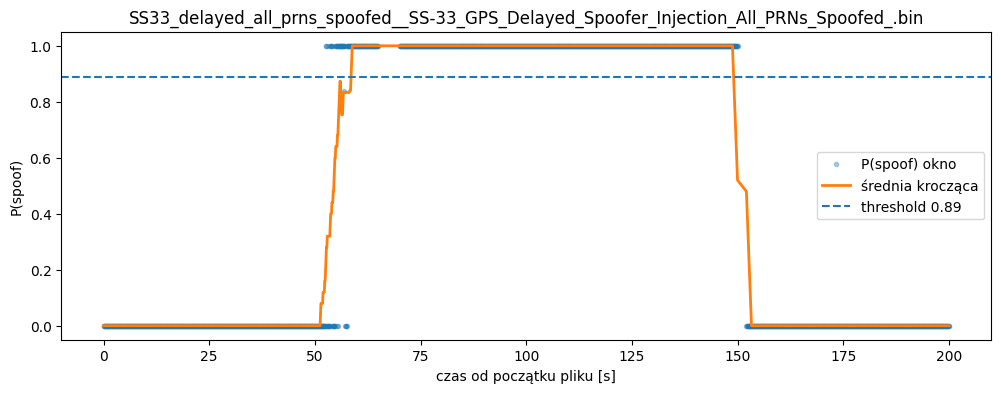

In [22]:
# Wykres P(spoof) po czasie dla plików testowych.
# Jeżeli zobaczysz skok z około 0 do około 1, to prawdopodobnie scenariusz zawiera fragment clean oraz fragment aktywnego ataku.

import matplotlib.pyplot as plt

if "test_diag_df" in globals() and len(test_diag_df) > 0:
    for file_name, g in test_diag_df.groupby("file"):
        g = g.sort_values("window_start_s").copy()
        g["p_smooth"] = g["y_proba"].rolling(25, center=True, min_periods=1).mean()

        plt.figure(figsize=(12, 4))
        plt.plot(g["window_start_s"], g["y_proba"], ".", alpha=0.35, label="P(spoof) okno")
        plt.plot(g["window_start_s"], g["p_smooth"], linewidth=2, label="średnia krocząca")
        thr = BEST_THRESHOLD if "BEST_THRESHOLD" in globals() else 0.5
        plt.axhline(thr, linestyle="--", label=f"threshold {thr:.2f}")
        plt.xlabel("czas od początku pliku [s]")
        plt.ylabel("P(spoof)")
        plt.title(file_name)
        plt.ylim(-0.05, 1.05)
        plt.legend()
        plt.show()
else:
    print("Najpierw uruchom komórkę tworzącą test_diag_df.")


In [23]:
# Bloki decyzji po czasie.
# To pokazuje, czy np. pierwsze 520 okien jest prawie zawsze clean, a następne 480 prawie zawsze spoof.

if "test_diag_df" in globals() and len(test_diag_df) > 0:
    block_tables = []

    for file_name, g in test_diag_df.groupby("file"):
        g = g.sort_values("window_start_s").copy()
        g["block"] = (g["y_pred"] != g["y_pred"].shift()).cumsum()

        blocks = (
            g.groupby(["file", "block", "y_pred"])
            .agg(
                n_windows=("y_pred", "size"),
                start_s=("window_start_s", "min"),
                end_s=("window_end_s", "max"),
                mean_p_spoof=("y_proba", "mean"),
                min_p_spoof=("y_proba", "min"),
                max_p_spoof=("y_proba", "max"),
            )
            .reset_index()
        )

        block_tables.append(blocks)

    blocks_df = pd.concat(block_tables, ignore_index=True)
    display(blocks_df)
else:
    print("Najpierw uruchom komórkę tworzącą test_diag_df.")


,file,block,y_pred,n_windows,start_s,end_s,mean_p_spoof,min_p_spoof,max_p_spoof
0,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,1,0,525,0.000000,52.426179,0.000098,0.000067,0.000143
1,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,2,1,2,52.523172,52.625408,0.999490,0.999466,0.999514
2,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,3,0,4,52.722401,53.026488,0.000134,0.000110,0.000161
3,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,4,1,1,53.123482,53.126103,0.999628,0.999628,0.999628
4,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,5,0,3,53.223096,53.427569,0.000122,0.000114,0.000135
5,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,6,1,1,53.524562,53.527183,0.998355,0.998355,0.998355
6,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,7,0,1,53.624177,53.626798,0.000089,0.000089,0.000089
7,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,8,1,3,53.723791,53.925642,0.999526,0.999420,0.999623
8,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,9,0,1,54.025257,54.027878,0.000130,0.000130,0.000130
9,SS33_delayed_all_prns_spoofed__SS-33_GPS_Delay...,10,1,1,54.124872,54.127493,0.999533,0.999533,0.999533


In [24]:
# Sprawdzenie temporal labels po treningu.
# Tu nie tworzymy już nowych etykiet — dataset użył ich podczas treningu.
# Ta komórka tylko pokazuje, jak model radzi sobie na etykietach czasowych.

if "test_diag_df" in globals() and len(test_diag_df) > 0:
    print("Temporal-label confusion matrix dla datasetu diagnostycznego:")
    print(confusion_matrix(test_diag_df["y_true"], test_diag_df["y_pred"]))
    print(classification_report(test_diag_df["y_true"], test_diag_df["y_pred"], digits=4, zero_division=0))

    if len(np.unique(test_diag_df["y_true"])) == 2:
        print("ROC-AUC:", roc_auc_score(test_diag_df["y_true"], test_diag_df["y_proba"]))
        print("PR-AUC:", average_precision_score(test_diag_df["y_true"], test_diag_df["y_proba"]))
else:
    print("Najpierw uruchom komórkę tworzącą test_diag_df.")


Temporal-label confusion matrix dla datasetu diagnostycznego:
[[1027  103]
 [   0  800]]
              precision    recall  f1-score   support

           0     1.0000    0.9088    0.9522      1130
           1     0.8859    1.0000    0.9395       800

    accuracy                         0.9466      1930
   macro avg     0.9430    0.9544    0.9459      1930
weighted avg     0.9527    0.9466    0.9470      1930

ROC-AUC: 0.9810110619469027
PR-AUC: 0.9506474271110223


In [25]:
# OPCJONALNY TEST SANITY CHECK: losowe etykiety.
# Uruchom tylko gdy chcesz sprawdzić leakage. Przy losowych etykietach wynik powinien być około 0.5.

RUN_SHUFFLED_LABEL_SANITY_CHECK = False

if RUN_SHUFFLED_LABEL_SANITY_CHECK:
    def make_label_shuffled_dataset(ds):
        ds2 = copy.deepcopy(ds)
        labels = [row[2] for row in ds2.index]
        random.shuffle(labels)
        ds2.index = [
            (file_idx, window_idx, int(new_label), window_start_s, window_end_s, scen)
            for (file_idx, window_idx, old_label, window_start_s, window_end_s, scen), new_label
            in zip(ds2.index, labels)
        ]
        return ds2

    train_ds_shuffled = make_label_shuffled_dataset(train_ds)

    shuffled_labels = np.array([row[2] for row in train_ds_shuffled.index], dtype=np.int64)
    shuffled_class_counts = np.bincount(shuffled_labels, minlength=2)
    shuffled_sample_weights = 1.0 / shuffled_class_counts[shuffled_labels]

    shuffled_sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(shuffled_sample_weights),
        num_samples=len(shuffled_sample_weights),
        replacement=True,
    )

    shuffled_loader = DataLoader(
        train_ds_shuffled,
        batch_size=BATCH_SIZE,
        sampler=shuffled_sampler,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    sanity_model = BiggerIQCNN().to(device)
    sanity_optimizer = torch.optim.AdamW(sanity_model.parameters(), lr=3e-4, weight_decay=1e-4)

    for epoch in range(1, 4):
        print(f"\nSanity epoch {epoch}/3")
        _ = run_one_epoch(sanity_model, shuffled_loader, optimizer=sanity_optimizer, device=device)
        sanity_val = run_one_epoch(sanity_model, val_loader, optimizer=None, device=device)
        print("sanity val_acc:", sanity_val["acc"])


In [26]:
from collections import Counter

train_labels = [row[2] for row in train_ds.index]
val_labels = [row[2] for row in val_ds.index]
print("Train class counts:", Counter(train_labels))
print("Val class counts:", Counter(val_labels))

print("\nTrain labels by scenario:")
display(dataset_index_df(train_ds).groupby(["scenario", "label"]).size().unstack(fill_value=0))
print("\nVal labels by scenario:")
display(dataset_index_df(val_ds).groupby(["scenario", "label"]).size().unstack(fill_value=0))


Train class counts: Counter({1: 10000, 0: 2000})
Val class counts: Counter({1: 2000, 0: 2000})

Train labels by scenario:


label,0,1
scenario,,
C5,2000,0
SS17,0,2000
SS18,0,2000
SS20,0,2000
SS27,0,2000
SS28,0,2000



Val labels by scenario:


label,0,1
scenario,,
C5,2000,0
SS29,0,2000


In [27]:
print(history_df)

   epoch  train_loss  train_acc  val_loss  val_acc
0      1    0.201936   0.986417  1.060209      0.5
1      2    0.018387   1.000000  0.013366      1.0
2      3    0.005855   1.000000  0.003184      1.0
3      4    0.002973   1.000000  0.001793      1.0
4      5    0.001861   1.000000  0.001042      1.0
5      6    0.001288   1.000000  0.000802      1.0
6      7    0.000945   1.000000  0.000601      1.0
7      8    0.000743   1.000000  0.000458      1.0
8      9    0.000578   1.000000  0.000406      1.0
9     10    0.000473   1.000000  0.000333      1.0


In [28]:
# Ewaluacja na train bez WeightedRandomSampler, żeby nie oceniać powtarzanych okien z losowaniem.

train_eval_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

train_eval = run_one_epoch(
    model,
    train_eval_loader,
    optimizer=None,
    device=device,
)

print("Train confusion matrix:")
print(confusion_matrix(train_eval["y_true"], train_eval["y_pred"]))

print("\nTrain report:")
print(classification_report(train_eval["y_true"], train_eval["y_pred"], digits=4, zero_division=0))

if len(np.unique(train_eval["y_true"])) == 2:
    print("Train ROC-AUC:", roc_auc_score(train_eval["y_true"], train_eval["y_proba"]))
    print("Train PR-AUC:", average_precision_score(train_eval["y_true"], train_eval["y_proba"]))


  0%|          | 0/47 [00:00<?, ?it/s]

Train confusion matrix:
[[ 2000     0]
 [    0 10000]]

Train report:
              precision    recall  f1-score   support

         0.0     1.0000    1.0000    1.0000      2000
         1.0     1.0000    1.0000    1.0000     10000

    accuracy                         1.0000     12000
   macro avg     1.0000    1.0000    1.0000     12000
weighted avg     1.0000    1.0000    1.0000     12000

Train ROC-AUC: 1.0
Train PR-AUC: 1.0


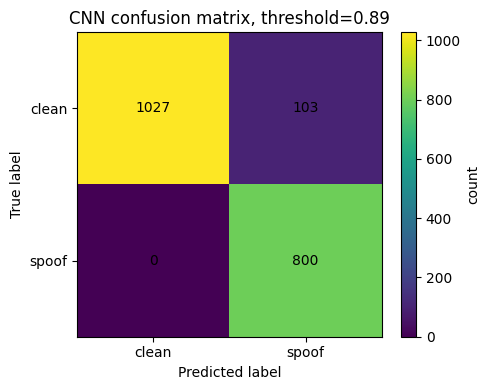

In [29]:
from sklearn.metrics import confusion_matrix

threshold = BEST_THRESHOLD if "BEST_THRESHOLD" in globals() else 0.5

y_true = test_diag_df["y_true"].to_numpy()
y_proba = test_diag_df["y_proba"].to_numpy()
y_pred = (y_proba >= threshold).astype(int)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"CNN confusion matrix, threshold={threshold:.2f}")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks([0, 1], ["clean", "spoof"])
plt.yticks([0, 1], ["clean", "spoof"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar(label="count")
plt.tight_layout()
plt.show()

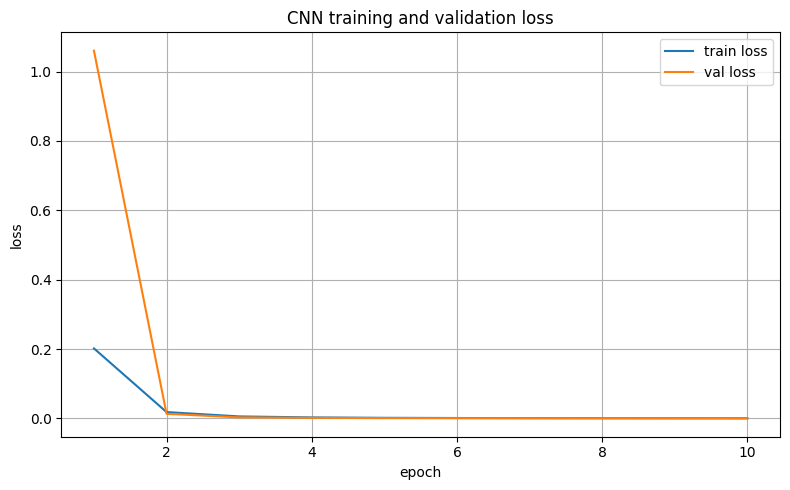

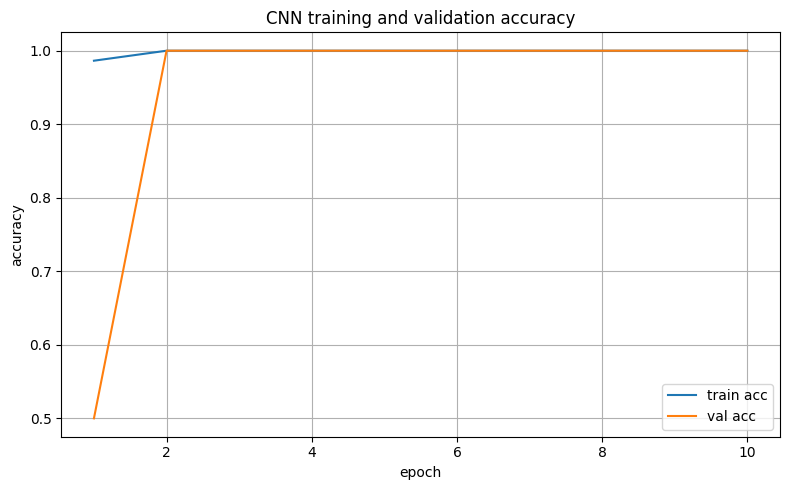

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("CNN training and validation loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="train acc")
plt.plot(history_df["epoch"], history_df["val_acc"], label="val acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("CNN training and validation accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

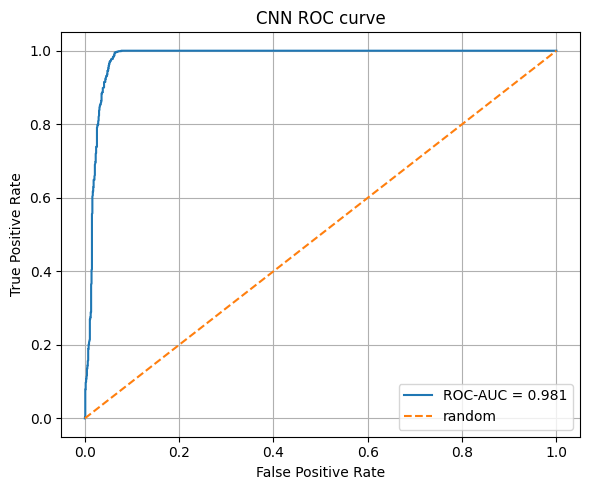

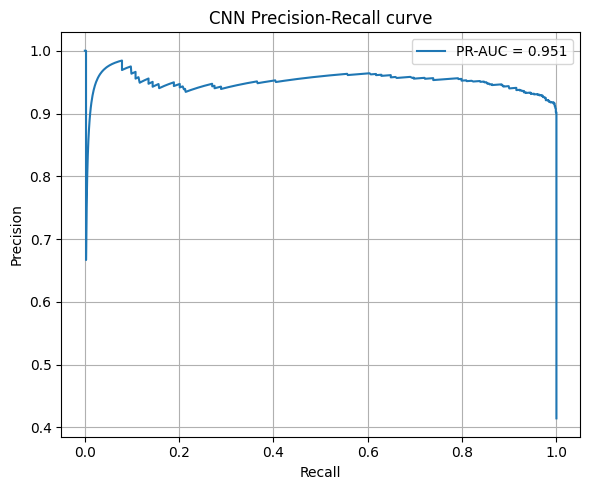

In [31]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

fpr, tpr, _ = roc_curve(y_true, y_proba)
precision, recall, _ = precision_recall_curve(y_true, y_proba)

roc_auc = roc_auc_score(y_true, y_proba)
pr_auc = average_precision_score(y_true, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN ROC curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CNN Precision-Recall curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

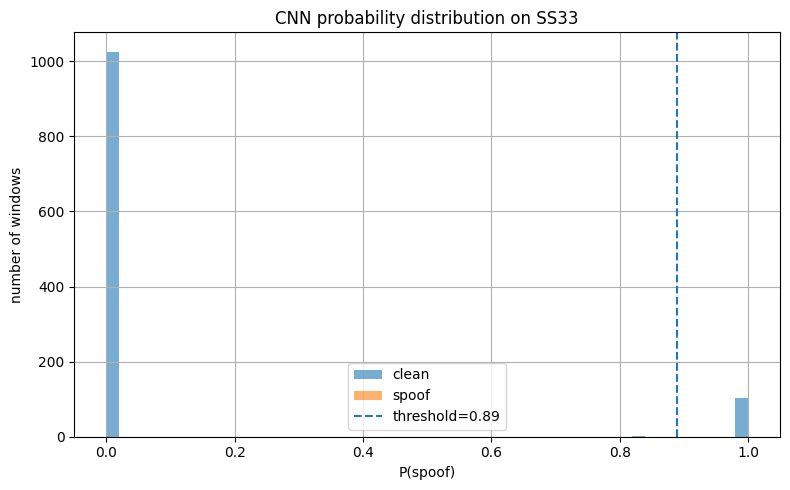

In [32]:
clean_probs = test_diag_df.loc[test_diag_df["y_true"] == 0, "y_proba"]
spoof_probs = test_diag_df.loc[test_diag_df["y_true"] == 1, "y_proba"]

plt.figure(figsize=(8, 5))
plt.hist(clean_probs, bins=50, alpha=0.6, label="clean")
plt.hist(spoof_probs, bins=50, alpha=0.6, label="spoof")
plt.axvline(threshold, linestyle="--", label=f"threshold={threshold:.2f}")
plt.xlabel("P(spoof)")
plt.ylabel("number of windows")
plt.title("CNN probability distribution on SS33")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

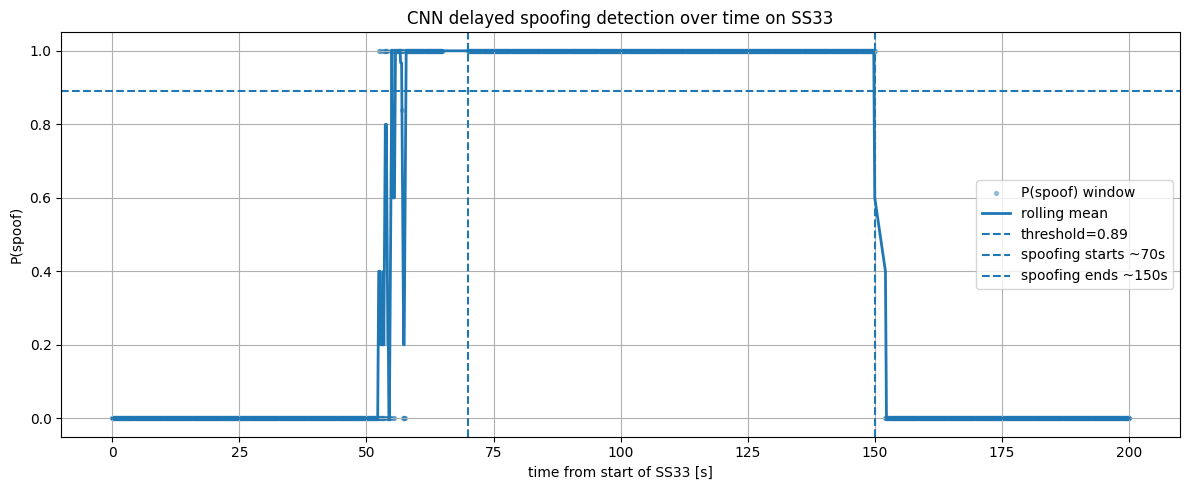

In [33]:
df_time = test_diag_df.sort_values("window_start_s").copy()

df_time["p_spoof_smooth"] = (
    df_time["y_proba"]
    .rolling(5, center=True, min_periods=1)
    .mean()
)

plt.figure(figsize=(12, 5))
plt.scatter(
    df_time["window_start_s"],
    df_time["y_proba"],
    s=8,
    alpha=0.4,
    label="P(spoof) window"
)
plt.plot(
    df_time["window_start_s"],
    df_time["p_spoof_smooth"],
    linewidth=2,
    label="rolling mean"
)

plt.axhline(threshold, linestyle="--", label=f"threshold={threshold:.2f}")
plt.axvline(70, linestyle="--", label="spoofing starts ~70s")
plt.axvline(150, linestyle="--", label="spoofing ends ~150s")

plt.xlabel("time from start of SS33 [s]")
plt.ylabel("P(spoof)")
plt.title("CNN delayed spoofing detection over time on SS33")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
import torch
import json
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, average_precision_score

EXPERIMENT_NAME = "cnn_raw_iq_tuni2025_v6_clean_timesplit"

cnn_threshold = BEST_THRESHOLD if "BEST_THRESHOLD" in globals() else 0.5

# Predykcje testowe
test_metrics = run_one_epoch(
    model,
    test_loader,
    optimizer=None,
    device=device,
)

cnn_y_true = np.array(test_metrics["y_true"])
cnn_y_proba = np.array(test_metrics["y_proba"])
cnn_y_pred = (cnn_y_proba >= cnn_threshold).astype(int)

cm = confusion_matrix(cnn_y_true, cnn_y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

cnn_metrics = {
    "model": "CNN",
    "input": "raw I/Q",
    "threshold": float(cnn_threshold),
    "WINDOW_SAMPLES": int(WINDOW_SAMPLES),
    "MAX_WINDOWS_PER_FILE": int(MAX_WINDOWS_PER_FILE),
    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),
    "accuracy": float(accuracy_score(cnn_y_true, cnn_y_pred)),
    "FPR": float(fp / (fp + tn)),
    "FNR": float(fn / (fn + tp)),
    "spoof_recall": float(tp / (tp + fn)),
    "spoof_precision": float(tp / (tp + fp)),
    "ROC_AUC": float(roc_auc_score(cnn_y_true, cnn_y_proba)),
    "PR_AUC": float(average_precision_score(cnn_y_true, cnn_y_proba)),
}

# 1. Klasyczny zapis state_dict
torch.save(
    model.state_dict(),
    MODELS_DIR / f"{EXPERIMENT_NAME}_state_dict.pt",
)

# 2. TorchScript — łatwiejszy do wczytania osobno
model.eval()
example_x, _ = next(iter(test_loader))
example_x = example_x[:1].to(device)

with torch.no_grad():
    traced_model = torch.jit.trace(model, example_x)

traced_model.save(str(MODELS_DIR / f"{EXPERIMENT_NAME}_torchscript.pt"))

# Konfiguracja
cnn_config = {
    "WINDOW_SAMPLES": int(WINDOW_SAMPLES),
    "MAX_WINDOWS_PER_FILE": int(MAX_WINDOWS_PER_FILE),
    "threshold": float(cnn_threshold),
    "sample_rate": 50_000_000,
    "input_shape": [2, int(WINDOW_SAMPLES)],
}

with open(REPORTS_DIR / f"{EXPERIMENT_NAME}_config.json", "w") as f:
    json.dump(cnn_config, f, indent=2)

with open(REPORTS_DIR / f"{EXPERIMENT_NAME}_metrics.json", "w") as f:
    json.dump(cnn_metrics, f, indent=2)

# Predykcje testowe
cnn_predictions_df = pd.DataFrame({
    "y_true": cnn_y_true,
    "y_proba": cnn_y_proba,
    "y_pred": cnn_y_pred,
})

if "test_index_df" in globals():
    idx_df = test_index_df.reset_index(drop=True)
    for col in ["source_file", "scenario", "window_start_s", "window_end_s"]:
        if col in idx_df.columns:
            cnn_predictions_df[col] = idx_df[col]

cnn_predictions_df.to_csv(
    REPORTS_DIR / f"{EXPERIMENT_NAME}_test_predictions.csv",
    index=False,
)

# Historia treningu
if "history_df" in globals():
    history_df.to_csv(
        REPORTS_DIR / f"{EXPERIMENT_NAME}_history.csv",
        index=False,
    )

print("Saved CNN artifacts.")

  0%|          | 0/8 [00:00<?, ?it/s]

Saved CNN artifacts.
